In [ ]:
# import json
# import shutil
# from pathlib import Path


# json_path = Path("predictions.json")
# fn_dir = Path("data/fp")
# fn_dir.mkdir(parents=True, exist_ok=True)

# classification_threshold = 0.5
# move_threshold = 0.7

# with json_path.open("r", encoding="utf-8") as file:
#     data = json.load(file)

# count = sum(
#     float(item["pred"]) >= classification_threshold
#     for item in data
# )

# moved_count = 0

# for index, item in enumerate(data):
#     probability = float(item["pred"])

#     if probability <= move_threshold:
#         continue

#     source = Path(item["image_path"])

#     if not source.is_file():
#         print(f"Missing image, skipped: {source}")
#         continue

#     destination = fn_dir / source.name

#     # Prevent files with identical names from overwriting each other.
#     if destination.exists():
#         destination = (
#             fn_dir
#             / f"{source.stem}_{index:07d}{source.suffix}"
#         )

#     shutil.move(str(source), str(destination))
#     item["image_path"] = str(destination)
#     moved_count += 1

#     print(f"Moved: {source} -> {destination}")

# total = len(data)
# ratio = count / total if total else 0

# # Save an updated JSON containing the new paths.
# with Path("predictions_moved.json").open(
#     "w",
#     encoding="utf-8",
# ) as file:
#     json.dump(data, file, indent=2)

# print(f"Predicted AI: {count}/{total}")
# print(f"AI ratio: {ratio:.2%}")
# print(f"Moved {moved_count} images to {fn_dir}")

Real images: 4894
AI-generated images: 3719
AUC: 0.9916


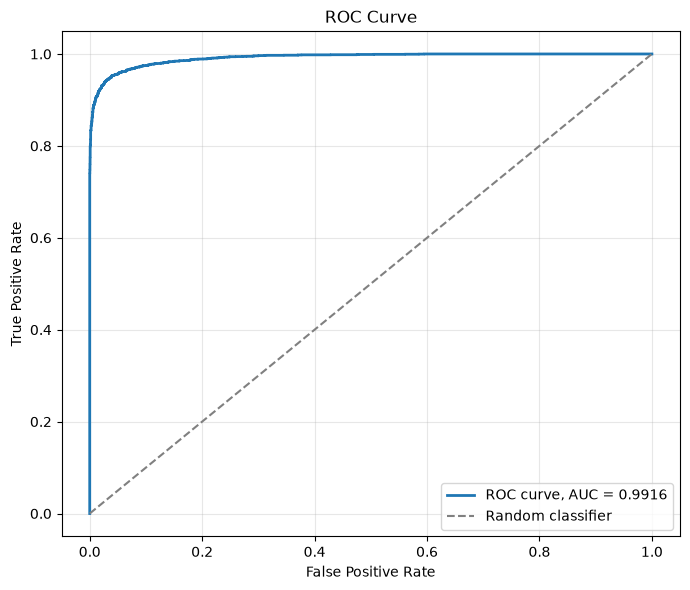

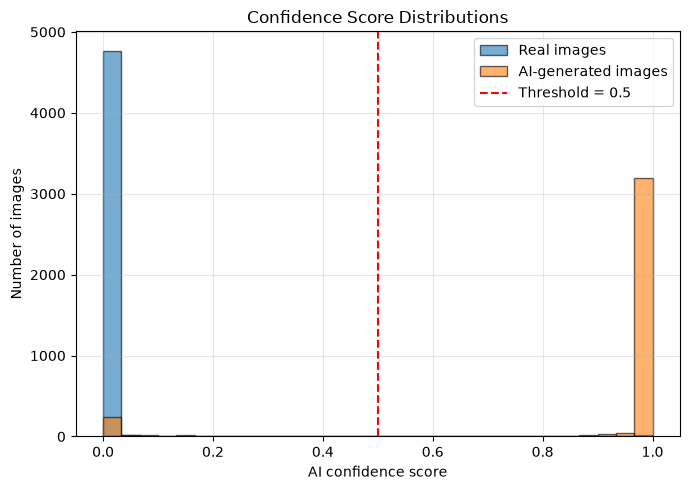

In [1]:
from pathlib import Path
import json

import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import roc_curve, roc_auc_score


JSON_PATH = "predictions.json"
THRESHOLD = 0.5


with open(JSON_PATH, "r") as f:
    data = json.load(f)


# Build labels and confidence scores
y_true = []
y_score = []

for item in data:
    filename = Path(item["image_path"]).name
    confidence = float(item["pred"])

    # COCO images are real (class 0); all others are AI-generated (class 1)
    label = 0 if filename.startswith("coco2017val_") else 1

    y_true.append(label)
    y_score.append(confidence)

y_true = np.asarray(y_true)
y_score = np.asarray(y_score)


# Check that both classes are present
print(f"Real images: {np.sum(y_true == 0)}")
print(f"AI-generated images: {np.sum(y_true == 1)}")

if len(np.unique(y_true)) < 2:
    raise ValueError(
        "ROC requires both class 0 and class 1, but only one class was found. "
        "Check the filename-labeling rule."
    )


# ROC curve and AUC
fpr, tpr, thresholds = roc_curve(y_true, y_score)
roc_auc = roc_auc_score(y_true, y_score)

print(f"AUC: {roc_auc:.4f}")


plt.figure(figsize=(7, 6))
plt.plot(
    fpr,
    tpr,
    linewidth=2,
    label=f"ROC curve, AUC = {roc_auc:.4f}",
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    color="gray",
    label="Random classifier",
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("roc_curve.png", dpi=300)
plt.show()


# Separate confidence distributions by true class
real_scores = y_score[y_true == 0]
ai_scores = y_score[y_true == 1]

plt.figure(figsize=(7, 5))

plt.hist(
    real_scores,
    bins=30,
    alpha=0.6,
    edgecolor="black",
    label="Real images",
)

plt.hist(
    ai_scores,
    bins=30,
    alpha=0.6,
    edgecolor="black",
    label="AI-generated images",
)

plt.axvline(
    THRESHOLD,
    color="red",
    linestyle="--",
    label=f"Threshold = {THRESHOLD}",
)

plt.xlabel("AI confidence score")
plt.ylabel("Number of images")
plt.title("Confidence Score Distributions")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("confidence_distribution.png", dpi=300)
plt.show()